[  0.       -12.515625 -22.203125] [0.         0.52930811 3.83320613] [ 0.      18.84375 31.8125 ]
[[11  0  0]
 [ 0  2 13]
 [27  0  0]]
0


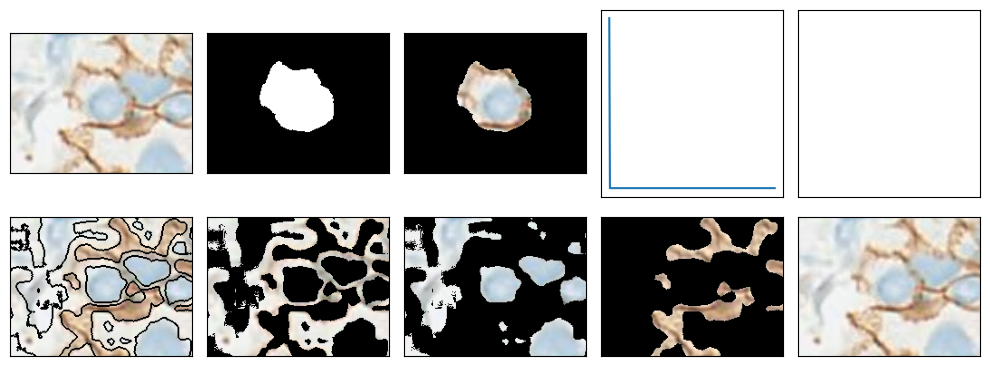

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.cluster.vq import kmeans, vq

# f = 3
f = 1
im = np.asarray(
    Image.open('C:/Users/pmaevskikh/Sources/cell.png').convert('RGB')
)
im = cv2.resize(im, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC)
h, w, _ = im.shape

mseg = Image.open('C:/Users/pmaevskikh/Sources/mask.png').convert('RGB')
mseg = (np.asarray(mseg) < 10).any(2).astype('u1')
mseg = cv2.morphologyEx(
    mseg,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
)
Image.fromarray(mseg * 255).save(
    'C:/Users/pmaevskikh/Sources/mask_ok.png'
)
mseg = cv2.resize(mseg, None, fx=f, fy=f, interpolation=cv2.INTER_NEAREST)
mseg = mseg.astype(bool)

# (n 3)
gain, igain = [0, 1, 1], 1
# gain, igain = [2.55, 2, 2], [1/2.55, .5, .5]
lab = cv2.cvtColor(im.astype('f4') / 255, cv2.COLOR_RGB2LAB) * gain
print(lab.min((0, 1)), lab.mean((0, 1)), lab.max((0, 1)))
lstar, a, b = cv2.split(lab)
lstar = lstar.astype('u1')
sat = np.hypot(a, b).clip(0, 255).astype('u1')

masks = []

# cluster by kmeans
k = 3
clusters, err = kmeans(lab[mseg], k)
print(
    (
        cv2.cvtColor(
            (clusters * igain)[None, :, :].astype('f4'),
            cv2.COLOR_LAB2RGB,
        )[0, :, :]
        * 255
    ).astype('u1')
)
ids, _ = vq(lab.reshape(-1, 3), clusters)
ids = ids.reshape(h, w)
mcs = ids[:, :, None] == np.arange(k)  # (h w k)
masks += list(mcs.transpose(2, 0, 1))
edges = cv2.morphologyEx(
    ids.astype('u1'),
    cv2.MORPH_GRADIENT,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
)

# histogram thresholding
cross = im * mseg[:, :, None]
hist = np.bincount(lstar[mseg], minlength=256)  # (256)
cdf = hist.cumsum().astype('f4')
t = np.searchsorted(cdf / cdf[-1], 0.35)
print(t)
m2 = lstar <= t
masks.append(m2)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes[0, 0].imshow(im)
axes[0, 1].imshow(mseg.astype('u1'), vmin=0, vmax=1, cmap='bone')
axes[0, 2].imshow(cross)
axes[0, 3].plot(hist)

axes[1, 0].imshow(im * np.where(edges[:, :, None], np.uint8(0), np.uint8(1)))
for i, m in enumerate(masks[:4], 1):
    axes[1, i].imshow(im * m[:, :, None])
for a in np.ravel(axes):
    a.set(xticks=[], yticks=[])
fig.tight_layout()
plt.show()